<a href="https://colab.research.google.com/github/Will-Emeka/St.Germain/blob/main/Wine_Quality_Prediction_Using_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download the Wine Quality dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

data = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")
print("Number of rows and columns:", data.shape)

# Display the first five rows
data.head()

Dataset loaded successfully!
Number of rows and columns: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
print("Dataset information:")
print(data.info())

print("\nMissing values:")
print(data.isnull().sum())

print("\nQuality distribution:")
print(data["quality"].value_counts().sort_index())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
resid

In [ ]:
data["quality_class"] = data["quality"].apply(
    lambda x: "Good" if x >= 6 else "Not Good"
)

print(data["quality_class"].value_counts())

quality_class
Good        855
Not Good    744
Name: count, dtype: int64


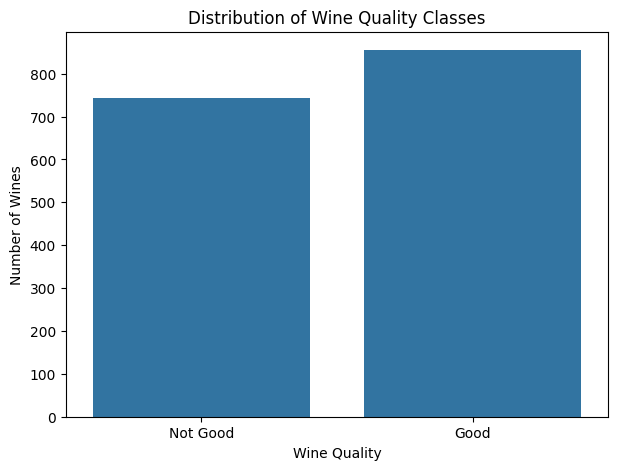

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="quality_class",
    data=data
)

plt.title("Distribution of Wine Quality Classes")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.show()

In [ ]:
X = data.drop(columns=["quality", "quality_class"])
y = data["quality_class"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality_class


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1279
Testing samples: 320


In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
['Not Good' 'Good' 'Not Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Not Good' 'Not Good' 'Not Good' 'Not Good' 'Good' 'Good' 'Good'
 'Not Good' 'Good' 'Not Good' 'Good']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 72.81 %

Classification Report:
              precision    recall  f1-score   support

        Good       0.75      0.73      0.74       171
    Not Good       0.70      0.72      0.71       149

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320



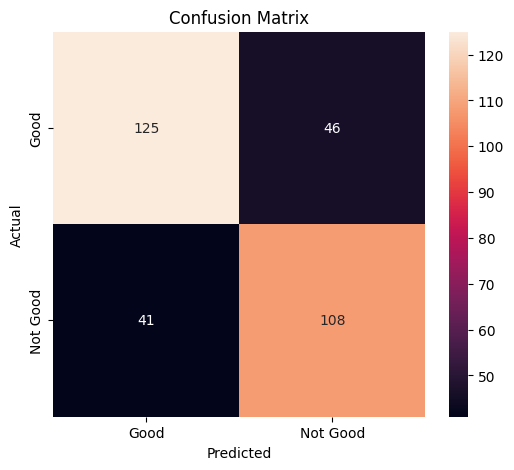

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Good", "Not Good"],
    yticklabels=["Good", "Not Good"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

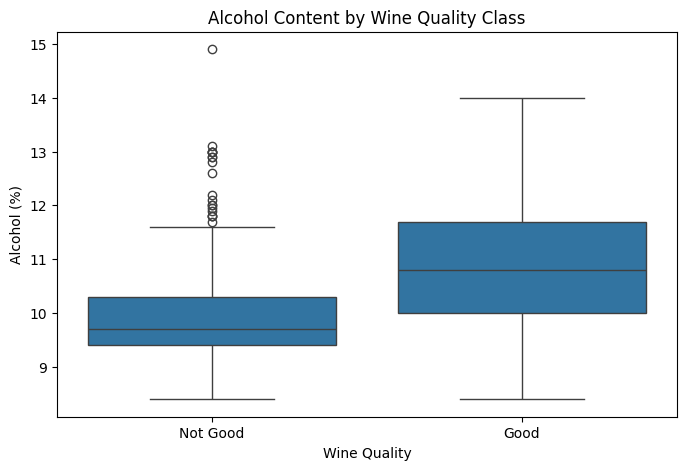

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="quality_class",
    y="alcohol",
    data=data
)

plt.title("Alcohol Content by Wine Quality Class")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol (%)")
plt.show()